# Loan Analytics: Default Prediction & Interest-Rate Modelling
### An end-to-end machine learning project on the LendingClub loan dataset

This notebook works on two related problems using the same data:

| Part | Problem | Type | Target |
|------|---------|------|--------|
| **A** | Loan Default Prediction | Classification | `not.fully.paid` |
| **B** | Interest-Rate Modelling | Regression | `int.rate` |

For each part the steps are: load & clean the data, explore it, encode the categorical column, split
into train and test, train and compare three models with cross-validation, look at what drives the
outcome, and save the best model. Part A also tunes the decision threshold and scores every loan.

Classification predicts a category (default or repaid); regression predicts a number (the interest
rate). Doing both shows the two main types of supervised learning on one dataset.

## 0. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_validate,
                                     StratifiedKFold, KFold, cross_val_predict)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import metrics
from xgboost import XGBRegressor

random_state = 50

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv('loan_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


The data has 9,578 loans and 14 columns:

| Column | Meaning |
|--------|---------|
| `credit.policy` | 1 if the borrower meets the lender's credit criteria, else 0 |
| `purpose` | Reason for the loan (the only text column) |
| `int.rate` | Interest rate of the loan, e.g. 0.12 = 12% (regression target in Part B) |
| `installment` | Fixed monthly payment |
| `log.annual.inc` | Natural log of annual income |
| `dti` | Debt-to-income ratio |
| `fico` | FICO credit score |
| `days.with.cr.line` | Days the borrower has had a credit line |
| `revol.bal` | Revolving balance (unpaid credit-card debt) |
| `revol.util` | Percent of the credit line being used |
| `inq.last.6mths` | Credit inquiries in the last 6 months |
| `delinq.2yrs` | Times 30+ days late in the past 2 years |
| `pub.rec` | Number of derogatory public records |
| `not.fully.paid` | Classification target (Part A): 1 = not repaid, 0 = repaid |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
df.describe().round(2)

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.0,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00,9578.00
mean,0.8,0.12,319.09,10.93,12.61,710.85,4560.77,16913.96,46.80,1.58,0.16,0.06,0.16
std,0.4,0.03,207.07,0.61,6.88,37.97,2496.93,33756.19,29.01,2.20,0.55,0.26,0.37
min,0.0,0.06,15.67,7.55,0.00,612.00,178.96,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.0,0.10,163.77,10.56,7.21,682.00,2820.00,3187.00,22.60,0.00,0.00,0.00,0.00
50%,1.0,0.12,268.95,10.93,12.66,707.00,4139.96,8596.00,46.30,1.00,0.00,0.00,0.00
75%,1.0,0.14,432.76,11.29,17.95,737.00,5730.00,18249.50,70.90,2.00,0.00,0.00,0.00
max,1.0,0.22,940.14,14.53,29.96,827.00,17639.96,1207359.00,119.00,33.00,13.00,5.00,1.00


### Data quality

In [5]:
print('Total missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print()
print('Loan purposes:')
print(df['purpose'].value_counts())

Total missing values: 0
Duplicate rows: 0

Loan purposes:
purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64


## 2. Exploratory Data Analysis

In [6]:
counts = df['not.fully.paid'].value_counts()
print('Repaid (0):', counts[0])
print('Not fully paid (1):', counts[1])
print('Default rate: %.2f%%' % (df['not.fully.paid'].mean()*100))

Repaid (0): 8045
Not fully paid (1): 1533
Default rate: 16.01%


Only about 16% of loans are not repaid, so the classes are imbalanced. This means accuracy will
be misleading in Part A (a model that predicts "everyone repays" already scores about 84%), so we use
F1, recall and ROC-AUC instead.

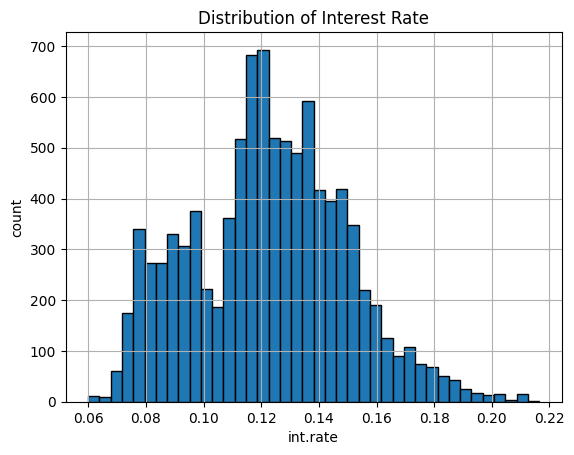

In [11]:
plt.figure()
df['int.rate'].hist(bins=40, edgecolor='black')
plt.title('Distribution of Interest Rate')
plt.xlabel('int.rate'); plt.ylabel('count')
plt.show()

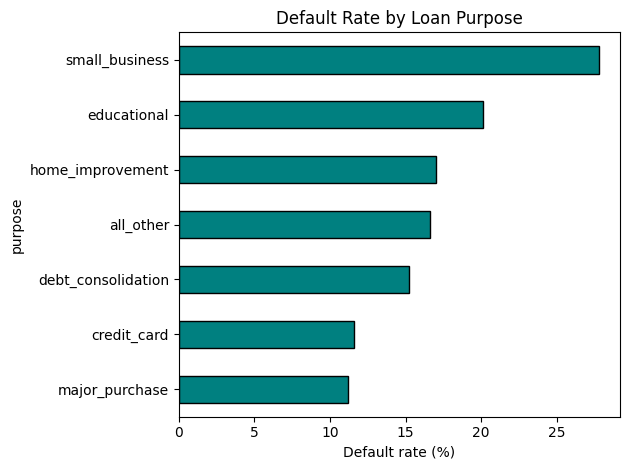

purpose
major_purchase        11.21
credit_card           11.57
debt_consolidation    15.24
all_other             16.60
home_improvement      17.01
educational           20.12
small_business        27.79
Name: not.fully.paid, dtype: float64

In [13]:
by_purpose = df.groupby('purpose')['not.fully.paid'].mean().sort_values()*100
plt.figure()
by_purpose.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default rate (%)')
plt.tight_layout(); plt.show()
by_purpose.round(2)

Small-business loans default most often; credit-card and major-purchase loans least often. Loan
purpose carries useful information.

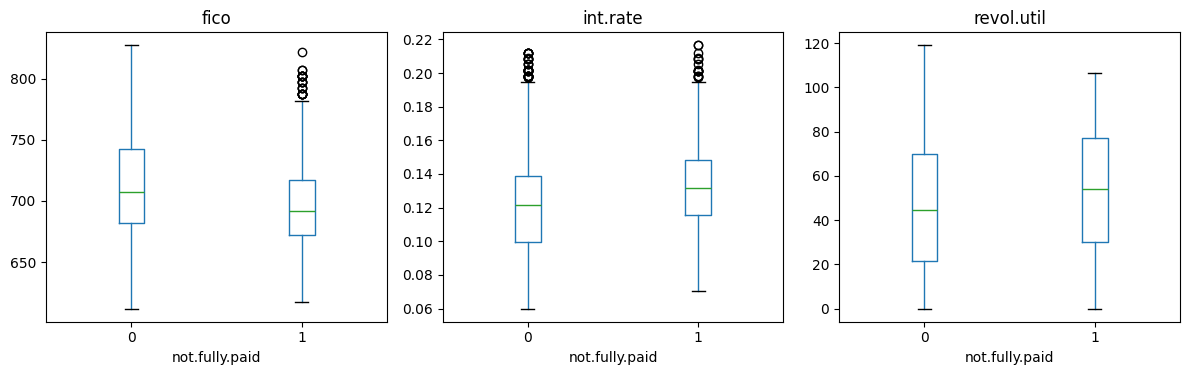

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, col in zip(ax, ['fico', 'int.rate', 'revol.util']):
    df.boxplot(column=col, by='not.fully.paid', ax=a, grid=False)
    a.set_xlabel('not.fully.paid'); a.set_title(col)
plt.suptitle('')
plt.tight_layout(); plt.show()

Borrowers who default tend to have lower FICO scores, higher interest rates, and higher credit
utilisation.

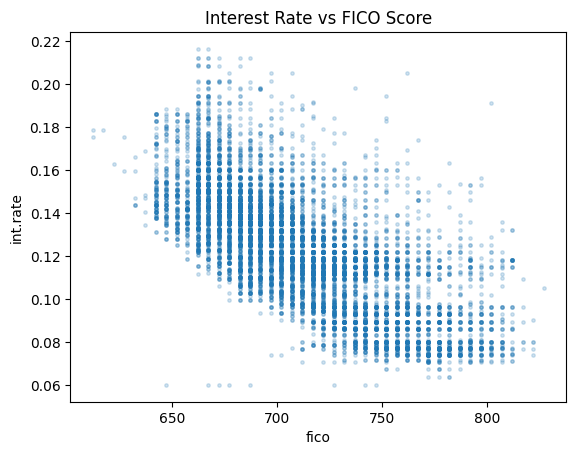

In [15]:
plt.figure()
plt.scatter(df['fico'], df['int.rate'], s=6, alpha=0.2)
plt.title('Interest Rate vs FICO Score')
plt.xlabel('fico'); plt.ylabel('int.rate')
plt.show()

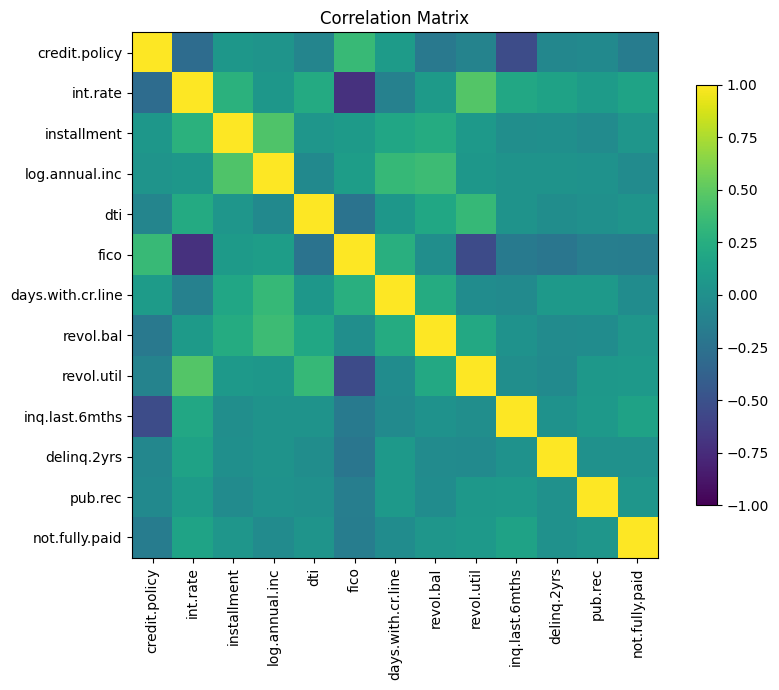

In [16]:
corr = df.drop(columns='purpose').corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(shrink=0.8)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

Interest rate is strongly and negatively correlated with FICO score: a lower score comes with a
higher rate. This is the relationship Part B models directly.

## 3. Feature Encoding

`purpose` is the only categorical column. We one-hot encode it with `drop_first=True`, which keeps
k-1 dummy columns for k categories (the dropped level becomes the baseline) and avoids the dummy
variable trap. All other columns are already numeric.

In [17]:
df_enc = pd.get_dummies(df, columns=['purpose'], drop_first=True)
print('Shape after encoding:', df_enc.shape)
df_enc.head()

Shape after encoding: (9578, 19)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


---
# Part A: Loan Default Prediction (Classification)

Goal: predict `not.fully.paid` so the lender can flag risky applications before approving them.

### A1. Train/Test Split



In [18]:
y_clf = df_enc['not.fully.paid']
X_clf = df_enc.drop(columns='not.fully.paid')

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.3, stratify=y_clf, random_state=random_state)
print('Train:', Xc_train.shape, ' Test:', Xc_test.shape)

Train: (6704, 18)  Test: (2874, 18)


### A2. Preprocessing

We scale the numeric columns with `StandardScaler`, placed inside a Pipeline so the scaler is re-fit
on only the training part of each cross-validation fold. Scaling everything up front would let the
validation folds see their own statistics, which is a form of data leakage.

In [19]:
numeric_features = ['int.rate','installment','log.annual.inc','dti','fico','days.with.cr.line',
                    'revol.bal','revol.util','inq.last.6mths','delinq.2yrs','pub.rec']
preprocess_clf = ColumnTransformer(
    transformers=[('scale', StandardScaler(), numeric_features)],
    remainder='passthrough')

### A3. Train  Classifiers


In [20]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Logistic Regression
log_pipe = Pipeline([('pre', preprocess_clf),
                     ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                                random_state=random_state))])
log_grid = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear']}
log_clf = GridSearchCV(log_pipe, log_grid, scoring='f1', cv=5, n_jobs=-1).fit(Xc_train, yc_train)
print('Logistic Regression best params:', log_clf.best_params_)
log_clf = log_clf.best_estimator_

Logistic Regression best params: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}


In [21]:
# Decision Tree
dt_pipe = Pipeline([('pre', preprocess_clf),
                    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=random_state))])
dt_grid = {'clf__max_depth': [3, 5, 7, 10], 'clf__min_samples_leaf': [5, 20, 50]}
dt_clf = GridSearchCV(dt_pipe, dt_grid, scoring='f1', cv=5, n_jobs=-1).fit(Xc_train, yc_train)
print('Decision Tree best params:', dt_clf.best_params_)
dt_clf = dt_clf.best_estimator_

Decision Tree best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 20}


In [23]:
# Random Forest
rf_clf = Pipeline([('pre', preprocess_clf),
                   ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                  random_state=random_state, n_jobs=-1))]).fit(Xc_train, yc_train)


### A4. Compare Models

Because the data is imbalanced we compare on F1, recall, precision and ROC-AUC (not accuracy), each
averaged over 5 cross-validation folds on the training set.

In [24]:
clf_models = {'Logistic Regression': log_clf,
              'Decision Tree': dt_clf,
              'Random Forest': rf_clf}

rows = []
for name, model in clf_models.items():
    r = cross_validate(model, Xc_train, yc_train, cv=cv5,
                       scoring=['accuracy','precision','recall','f1','roc_auc'])
    rows.append({'Model': name,
                 'Accuracy': round(r['test_accuracy'].mean()*100, 2),
                 'Precision': round(r['test_precision'].mean()*100, 2),
                 'Recall': round(r['test_recall'].mean()*100, 2),
                 'F1': round(r['test_f1'].mean()*100, 2),
                 'ROC-AUC': round(r['test_roc_auc'].mean()*100, 2)})
clf_comparison = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
clf_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,64.42,24.55,59.09,34.68,68.21
1,Decision Tree,71.57,26.51,43.44,32.84,63.54
2,Random Forest,81.76,34.33,15.10,20.94,66.57


Predicting default from these features is genuinely hard, so the scores are modest but honest.
Logistic Regression is best on F1 and ROC-AUC and catches the most defaulters (highest recall), so we
use it as the best model. Note that Random Forest has the highest accuracy but catches almost no
defaulters, which is exactly why accuracy is the wrong metric here.

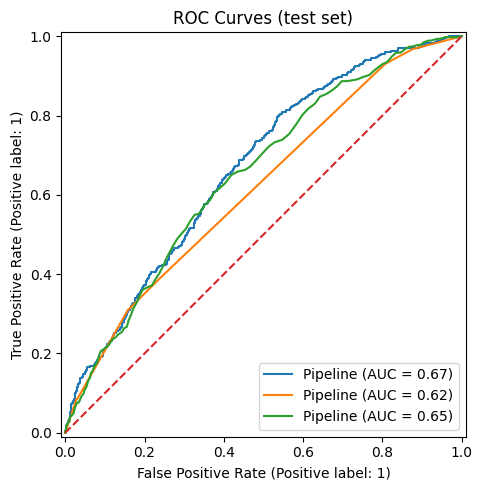

In [25]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in clf_models.items():
    RocCurveDisplay.from_estimator(model, Xc_test, yc_test, ax=ax)
ax.plot([0, 1], [0, 1], '--')
ax.set_title('ROC Curves (test set)')
plt.tight_layout(); plt.show()

### A5. Evaluate the Best Classifier

Best classifier: Logistic Regression

              precision    recall  f1-score   support

      Repaid       0.89      0.65      0.75      2414
     Default       0.24      0.57      0.33       460

    accuracy                           0.64      2874
   macro avg       0.56      0.61      0.54      2874
weighted avg       0.78      0.64      0.69      2874



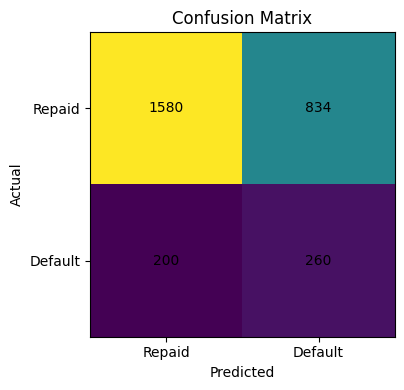

In [28]:
best_clf_name = clf_comparison.iloc[0]['Model']
best_clf = clf_models[best_clf_name]
print('Best classifier:', best_clf_name)

yc_pred = best_clf.predict(Xc_test)
print()
print(metrics.classification_report(yc_test, yc_pred, target_names=['Repaid', 'Default']))

cm = metrics.confusion_matrix(yc_test, yc_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm)
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Repaid', 'Default'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Repaid', 'Default'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

### A6. What Drives Default?

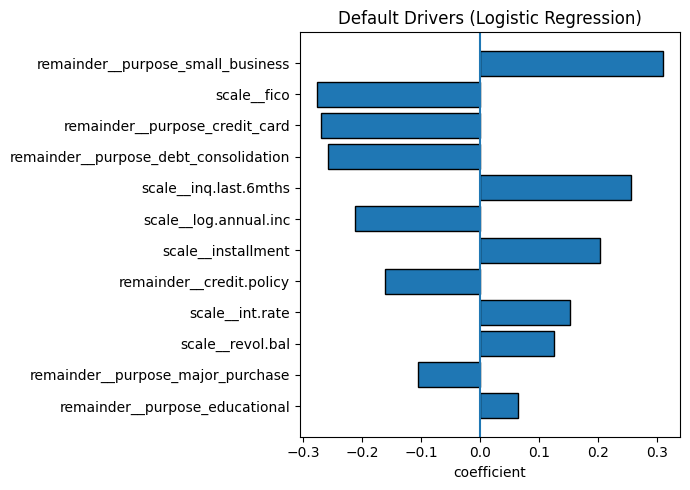

In [29]:
clf = best_clf.named_steps['clf']
feat_names = best_clf.named_steps['pre'].get_feature_names_out()
importance = clf.coef_[0] if hasattr(clf, 'coef_') else clf.feature_importances_

imp = (pd.DataFrame({'feature': feat_names, 'importance': importance})
       .assign(abs_imp=lambda d: d['importance'].abs())
       .sort_values('abs_imp', ascending=False).head(12))
plt.figure(figsize=(7, 5))
plt.barh(imp['feature'][::-1], imp['importance'][::-1], edgecolor='black')
plt.axvline(0)
plt.title('Default Drivers (' + best_clf_name + ')')
plt.xlabel('coefficient')
plt.tight_layout(); plt.show()

Higher interest rate, more recent credit inquiries, and higher utilisation raise default risk,
while a higher FICO score and meeting the credit policy lower it. These match the EDA.

### A7. Decision Threshold

`.predict()` uses a 0.5 cutoff by default. Sweeping the threshold shows the trade-off between
precision and recall the lender can choose from.

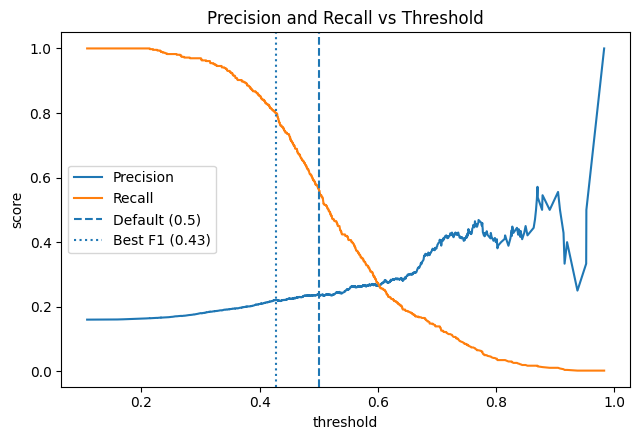

Best-F1 threshold: 0.428  precision=0.221  recall=0.800  f1=0.347


In [30]:
from sklearn.metrics import precision_recall_curve, f1_score
probs = best_clf.predict_proba(Xc_test)[:, 1]
prec, rec, thr = precision_recall_curve(yc_test, probs)
f1s = 2*prec*rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1s[:-1]); best_thr = thr[best_idx]

plt.figure(figsize=(6.5, 4.5))
plt.plot(thr, prec[:-1], label='Precision')
plt.plot(thr, rec[:-1], label='Recall')
plt.axvline(0.5, ls='--', label='Default (0.5)')
plt.axvline(best_thr, ls=':', label='Best F1 (%.2f)' % best_thr)
plt.xlabel('threshold'); plt.ylabel('score')
plt.title('Precision and Recall vs Threshold')
plt.legend(); plt.tight_layout(); plt.show()
print('Best-F1 threshold: %.3f  precision=%.3f  recall=%.3f  f1=%.3f'
      % (best_thr, prec[best_idx], rec[best_idx], f1s[best_idx]))

### A8. Score Every Loan

We use `cross_val_predict` with a fresh clone of the model, so each loan's probability comes from a
model that never trained on it. This gives an honest risk score for ranking the whole loan book.

In [31]:
from sklearn.base import clone
oof_probs = cross_val_predict(clone(log_clf), X_clf, y_clf, cv=cv5,
                              method='predict_proba', n_jobs=-1)[:, 1]
scored = df.copy()
scored['default_probability'] = oof_probs
scored[['purpose', 'fico', 'int.rate', 'dti', 'not.fully.paid', 'default_probability']] \
    .sort_values('default_probability', ascending=False).head(10)

,purpose,fico,int.rate,dti,not.fully.paid,default_probability
9535,small_business,717,0.1496,11.38,1,0.995604
9042,small_business,672,0.2011,14.39,0,0.994983
8409,credit_card,657,0.1324,6.99,1,0.983007
7714,debt_consolidation,652,0.1482,19.12,1,0.980952
8037,all_other,662,0.1217,14.85,0,0.975702
8026,debt_consolidation,642,0.1375,16.71,0,0.967943
8018,small_business,682,0.1028,8.96,0,0.965244
7919,debt_consolidation,667,0.1754,25.63,0,0.955978
8324,credit_card,652,0.1418,1.49,0,0.945225
8062,all_other,642,0.1438,21.34,0,0.939682


### A9. Save the Classifier

In [32]:
joblib.dump(best_clf, 'loan_default_model.pkl')
joblib.dump(list(X_clf.columns), 'default_model_columns.pkl')
print('Saved', best_clf_name, '-> loan_default_model.pkl')

Saved Logistic Regression -> loan_default_model.pkl


---
# Part B: Interest-Rate Modelling (Regression)

Goal: predict `int.rate` from the borrower's profile. This shows how the lender prices risk, and a
good model could flag loans whose rate looks out of line with the borrower's risk.



### B1. Split and Preprocess

In [33]:
y_reg = df_enc['int.rate']
X_reg = df_enc.drop(columns='int.rate')

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=random_state)   
print('Train:', Xr_train.shape, ' Test:', Xr_test.shape)

numeric_reg = ['installment','log.annual.inc','dti','fico','days.with.cr.line','revol.bal',
               'revol.util','inq.last.6mths','delinq.2yrs','pub.rec']
preprocess_reg = ColumnTransformer(
    transformers=[('scale', StandardScaler(), numeric_reg)], remainder='passthrough')

Train: (6704, 18)  Test: (2874, 18)


### B2. Train and Compare Three Regressors

We compare a linear baseline, a Random Forest, and XGBoost, using 5-fold cross-validation and
reporting R2 (variance explained), RMSE and MAE (average error in interest-rate points).

In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

reg_models = {
    'Linear Regression': Pipeline([('pre', preprocess_reg), ('reg', LinearRegression())]),
    'Random Forest':     Pipeline([('pre', preprocess_reg),
                                   ('reg', RandomForestRegressor(n_estimators=200,
                                           random_state=random_state, n_jobs=-1))]),
    'XGBoost':           Pipeline([('pre', preprocess_reg),
                                   ('reg', XGBRegressor(n_estimators=300, max_depth=4,
                                           learning_rate=0.05, subsample=0.9,
                                           colsample_bytree=0.9, random_state=random_state))]),
}

rows = []
for name, model in reg_models.items():
    r = cross_validate(model, Xr_train, yr_train, cv=kf,
                       scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'])
    rows.append({'Model': name,
                 'R2': round(r['test_r2'].mean(), 4),
                 'RMSE': round(-r['test_neg_root_mean_squared_error'].mean(), 5),
                 'MAE': round(-r['test_neg_mean_absolute_error'].mean(), 5)})
reg_comparison = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
reg_comparison

,Model,R2,RMSE,MAE
0,XGBoost,0.7614,0.01311,0.00926
1,Random Forest,0.7432,0.01360,0.00939
2,Linear Regression,0.6608,0.01564,0.01181


XGBoost explains the most variance with the lowest error. Interest rate is largely a function of
risk features, so the tree ensembles capture the pricing rules better than the linear model. This is
the opposite of Part A, where the simple model won, which shows the best model depends on the
problem.

In [35]:
best_reg_name = reg_comparison.iloc[0]['Model']
best_reg = reg_models[best_reg_name].fit(Xr_train, yr_train)
yr_pred = best_reg.predict(Xr_test)
print('Best regressor:', best_reg_name)
print('Test R2  : %.4f' % metrics.r2_score(yr_test, yr_pred))
print('Test RMSE: %.5f' % metrics.root_mean_squared_error(yr_test, yr_pred))
print('Test MAE : %.5f' % metrics.mean_absolute_error(yr_test, yr_pred))

Best regressor: XGBoost
Test R2  : 0.7570
Test RMSE: 0.01320
Test MAE : 0.00935


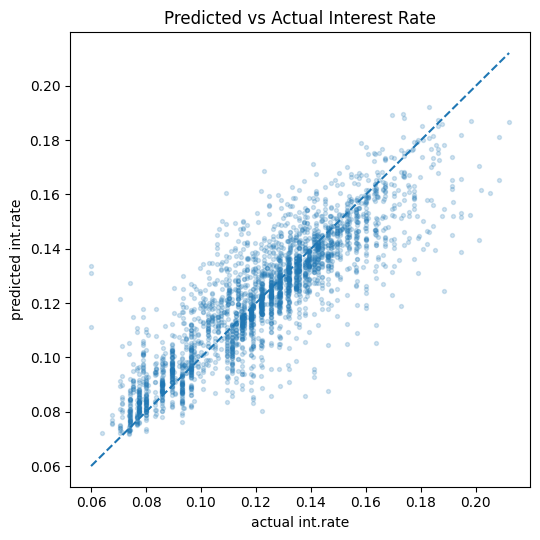

In [36]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(yr_test, yr_pred, s=8, alpha=0.2)
lims = [yr_test.min(), yr_test.max()]
plt.plot(lims, lims, '--')
plt.xlabel('actual int.rate'); plt.ylabel('predicted int.rate')
plt.title('Predicted vs Actual Interest Rate')
plt.tight_layout(); plt.show()

### B3. What Drives the Interest Rate?

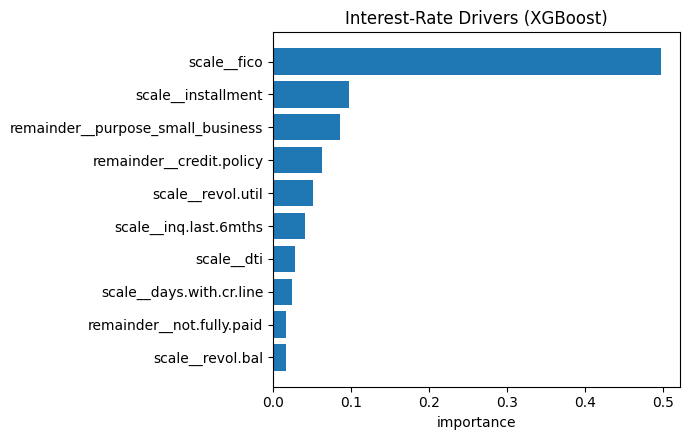

In [37]:
reg = best_reg.named_steps['reg']
feat_names_r = best_reg.named_steps['pre'].get_feature_names_out()
imp_r = (pd.DataFrame({'feature': feat_names_r,
                       'importance': reg.feature_importances_ if hasattr(reg, 'feature_importances_')
                                     else np.abs(reg.coef_)})
         .sort_values('importance', ascending=False).head(10))
plt.figure(figsize=(7, 4.5))
plt.barh(imp_r['feature'][::-1], imp_r['importance'][::-1])
plt.title('Interest-Rate Drivers (' + best_reg_name + ')')
plt.xlabel('importance')
plt.tight_layout(); plt.show()

FICO score is by far the biggest driver of the interest rate, followed by the credit policy flag
and utilisation. The rate is essentially a price set on creditworthiness, as the EDA scatter
suggested.

### B4. Save the Regressor

In [38]:
joblib.dump(best_reg, 'interest_rate_model.pkl')
joblib.dump(list(X_reg.columns), 'rate_model_columns.pkl')
print('Saved', best_reg_name, '-> interest_rate_model.pkl')

Saved XGBoost -> interest_rate_model.pkl


---
# Conclusion

**Part A (default prediction):** The best model was Logistic Regression, chosen on F1 and ROC-AUC. It
also caught the most defaulters. Default is hard to predict from these features, so scores are modest
but honest. The main drivers are interest rate, recent credit inquiries and utilisation, with FICO
score and meeting the credit policy being protective.

**Part B (interest-rate modelling):** The best model was XGBoost, explaining about 76% of the variance
in interest rate. FICO score is the dominant driver, so the rate is largely a risk-based price.

**How a lender could use this:**
1. Score new applications with the default model and send high-risk ones to manual review, using a
   threshold that reflects the cost of a bad loan versus a lost customer.
2. Compare each loan's actual rate to the predicted rate to check pricing.
3. Rank the existing loans by default probability to focus monitoring effort.

**Skills shown:** data cleaning, EDA, one-hot encoding, leakage-safe pipelines, cross-validation,
hyperparameter tuning, handling class imbalance, threshold tuning, and both classification and
regression, plus saving models for later use.

**Limitations:** the data is a single historical snapshot, so it should be revalidated over time;
correlation is not causation; and the decision threshold still needs real cost figures from the
business.